In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import *

from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy


In [32]:
!wget -nc https://lazyprogrammer.me/course_files/AirlineTweets.csv

File ‘AirlineTweets.csv’ already there; not retrieving.



In [33]:
np.random.seed(0)
tf.random.set_seed(0)

In [34]:
df = pd.read_csv('AirlineTweets.csv')

In [35]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [36]:
df = df[['airline_sentiment','text']]

<Axes: >

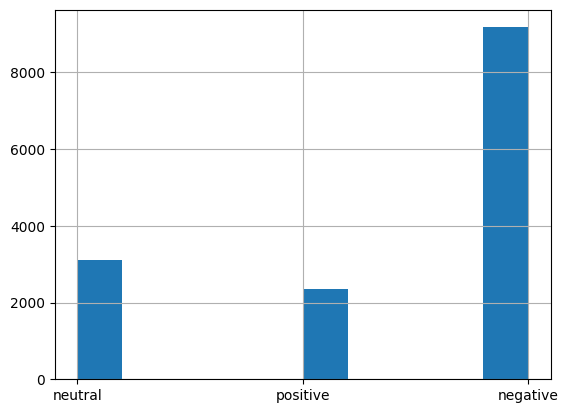

In [37]:
df['airline_sentiment'].hist()

In [38]:
df = df[df['airline_sentiment'] != 'neutral'].copy()

In [39]:
target_map = {'positive':1,
              'negative': 0}
df['target'] = df['airline_sentiment'].map(target_map)

In [40]:
df.head()

,airline_sentiment,text,target
1,positive,@VirginAmerica plus you've added commercials t...,1
3,negative,@VirginAmerica it's really aggressive to blast...,0
4,negative,@VirginAmerica and it's a really big bad thing...,0
5,negative,@VirginAmerica seriously would pay $30 a fligh...,0
6,positive,"@VirginAmerica yes, nearly every time I fly VX...",1


In [41]:
df_train, df_test = train_test_split(df, random_state = 42)

In [42]:
vectorizer = TfidfVectorizer(max_features = 2000)
X_train = vectorizer.fit_transform(df_train['text'])
X_test = vectorizer.transform(df_test['text'])

In [44]:
# data must not be sparse matrix before passing into tensorflow

X_train = X_train.toarray()
X_test = X_test.toarray()

In [45]:
Y_train = df_train['target']
Y_test = df_test['target']

In [46]:
# input Dimensions

D = X_train.shape[1]

In [47]:
D

2000

In [48]:
# build model
i = Input(shape = (D,))
x= Dense(1)(i)

model = Model(i,x)

In [49]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 2000)]            0         
                                                                 
 dense_1 (Dense)             (None, 1)                 2001      
                                                                 
Total params: 2001 (7.82 KB)
Trainable params: 2001 (7.82 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [50]:
model.compile(
    loss = BinaryCrossentropy(from_logits = True),
    optimizer = Adam(learning_rate = 0.01),
    metrics= ['accuracy']
)

In [55]:
r = model.fit(
    X_train, Y_train,
    validation_data = (X_test, Y_test),
    epochs = 25,
    batch_size = 32
)

Epoch 1/25
271/271 [==============================] - 3s 9ms/step - loss: 0.0863 - accuracy: 0.9667 - val_loss: 0.2054 - val_accuracy: 0.9213
Epoch 2/25
271/271 [==============================] - 2s 6ms/step - loss: 0.0826 - accuracy: 0.9678 - val_loss: 0.2083 - val_accuracy: 0.9207
Epoch 3/25
271/271 [==============================] - 2s 9ms/step - loss: 0.0798 - accuracy: 0.9695 - val_loss: 0.2116 - val_accuracy: 0.9217
Epoch 4/25
271/271 [==============================] - 1s 5ms/step - loss: 0.0776 - accuracy: 0.9712 - val_loss: 0.2143 - val_accuracy: 0.9207
Epoch 5/25
271/271 [==============================] - 1s 5ms/step - loss: 0.0756 - accuracy: 0.9713 - val_loss: 0.2174 - val_accuracy: 0.9203
Epoch 6/25
271/271 [==============================] - 1s 5ms/step - loss: 0.0742 - accuracy: 0.9728 - val_loss: 0.2203 - val_accuracy: 0.9203
Epoch 7/25
271/271 [==============================] - 1s 4ms/step - loss: 0.0724 - accuracy: 0.9726 - val_loss: 0.2231 - val_accuracy: 0.9210
Epoch 

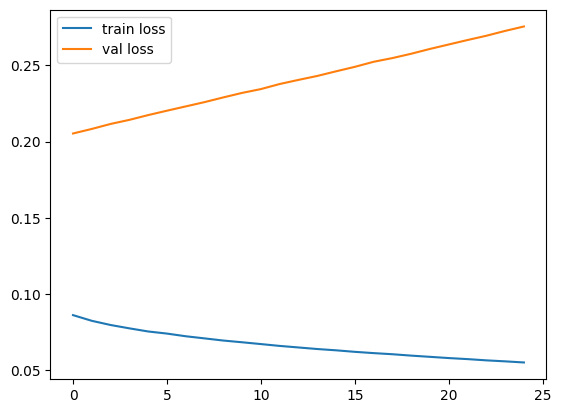

In [57]:
# Plot loss per iteration

plt.plot(r.history['loss'], label = 'train loss')
plt.plot(r.history['val_loss'], label = 'val loss')
plt.legend()


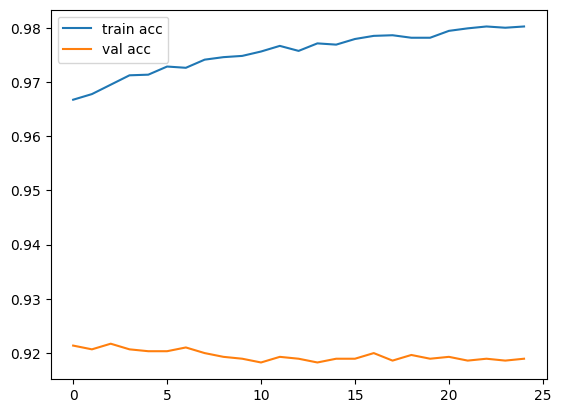

In [58]:
# Plot accuracy per iteration

plt.plot(r.history['accuracy'], label = 'train acc')
plt.plot(r.history['val_accuracy'], label = 'val acc')
plt.legend()

In [56]:
P_train = ((model.predict(X_train) > 0)*1.0).flatten()
P_test = ((model.predict(X_test) > 0)*1.0).flatten()

91/91 [==============================] - 0s 3ms/step


In [59]:
cm = confusion_matrix(Y_train, P_train, normalize = 'true')
cm

array([[0.99299781, 0.00700219],
       [0.03611111, 0.96388889]])

In [60]:
def plot_cm(cm):
  classes = ['positive','negative']
  df_cm = pd.DataFrame(cm, index = classes, columns = classes)
  ax = sns.heatmap(df_cm, annot = True, fmt = 'g')
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Target')


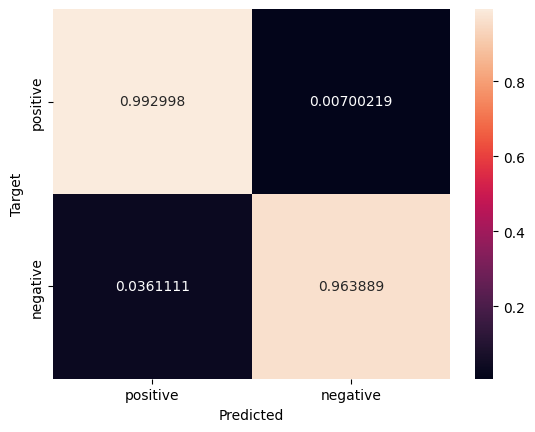

In [61]:
plot_cm(cm)

In [62]:
Pr_train = model.predict(X_train)
Pr_test = model.predict(X_test)
print("Train AUC:", roc_auc_score(Y_train, Pr_train))
print("Test AUC:", roc_auc_score(Y_test, Pr_test))


91/91 [==============================] - 0s 2ms/step
Train AUC: 0.9983822027716995
Test AUC: 0.9417493915581998


In [63]:
print('Train F1:', f1_score(Y_train, P_train))
print('Test F1:', f1_score(Y_test, P_test))

Train F1: 0.9684621825286074
Test F1: 0.7876588021778584


In [65]:
model.layers

In [69]:
W = model.layers[1].get_weights()[0]


In [70]:
word_index_map = vectorizer.vocabulary_
word_index_map

{'jetblue': 973,
 'thanks': 1726,
 'for': 753,
 'having': 855,
 'us': 1859,
 'hang': 838,
 'out': 1262,
 'at': 197,
 'tampa': 1708,
 'airport': 122,
 'forever': 756,
 'today': 1767,
 'it': 964,
 'really': 1420,
 'been': 243,
 'an': 147,
 'awesome': 217,
 'experience': 654,
 'americanair': 143,
 'was': 1898,
 'told': 1770,
 'you': 1993,
 'could': 452,
 'only': 1245,
 'refund': 1434,
 'me': 1107,
 'the': 1730,
 'cost': 448,
 'of': 1224,
 'my': 1179,
 'original': 1254,
 'return': 1476,
 'flight': 726,
 'note': 1211,
 'had': 828,
 'booked': 273,
 'more': 1164,
 'expensive': 653,
 'everyone': 635,
 'else': 602,
 'outstanding': 1267,
 'united': 1842,
 'denver': 516,
 'to': 1766,
 'austin': 207,
 'still': 1660,
 'on': 1239,
 'ground': 820,
 'issue': 961,
 'is': 959,
 'lack': 999,
 'announcement': 151,
 'made': 1086,
 'so': 1606,
 'late': 1010,
 'when': 1929,
 'gate': 793,
 'agent': 113,
 'there': 1734,
 'over': 1268,
 'hour': 897,
 'southwestair': 1626,
 'hold': 880,
 '30': 36,
 'min': 1141,


In [72]:
# lets look at the weights for each word
# try it with different threshold value

threshold = 2
print("Most Positive Words:")
word_weights_tuples = []
for word, index in word_index_map.items():
  weight = W[index,0]
  if weight > threshold:
    word_weights_tuples.append((word,weight))

word_weights_tuples = sorted(word_weights_tuples, key = lambda x: -x[1])
for i in range(10):
  word, weight = word_weights_tuples[i]
  print(word, weight)

Most Positive Words:
worries 18.673393
thank 17.724052
thanks 16.012915
excellent 14.981184
kudos 13.7221575
great 12.833458
love 12.564697
awesome 11.737177
hot 11.204239
love_dragonss 10.832734


In [73]:
# lets look at the weights for each word
# try it with different threshold value

print("Most Negative Words:")
word_weights_tuples = []
for word, index in word_index_map.items():
  weight = W[index,0]
  if weight <- threshold:
    word_weights_tuples.append((word,weight))

word_weights_tuples = sorted(word_weights_tuples, key = lambda x: x[1])
for i in range(10):
  word, weight = word_weights_tuples[i]
  print(word, weight)

Most Negative Words:
worst -22.216013
rude -18.759766
paid -16.875303
disappointed -16.75241
instead -15.881742
online -15.217776
hr -14.445203
worse -13.987209
hung -13.884394
rebook -13.850656
